In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Physical parameters
alpha = 1.0   # thermal diffusivity
L = 1.0       # length of rod

# Spatial grid
Nx = 100
x = np.linspace(0, L, Nx)

# Time points for visualization
times = [0, 0.01, 0.05, 0.1]

# Initial condition
def initial_condition(x):
    return np.sin(np.pi * x)

# Boundary conditions (for reference)
def left_bc(t):
    return 0.0

def right_bc(t):
    return 0.0

In [3]:
def get_modes():
    """
    Returns Fourier modes for the initial condition.
    u(x,0) = Σ A_n sin(nπx)
    """
    return [
        (1, 1.0),   # sin(pi x)
    ]

In [4]:
def analytical_solution(x, t, alpha, modes):
    """
    Computes u(x,t) using analytical solution
    """
    u = np.zeros_like(x)

    for n, A in modes:
        u += A * np.exp(-alpha * (n * np.pi)**2 * t) * np.sin(n * np.pi * x)

    return u

In [5]:
def plot_solution(x, times, solver, **kwargs):
    plt.figure()

    for t in times:
        u = solver(x, t, **kwargs)
        plt.plot(x, u, label=f"t={t}")

    plt.xlabel("x")
    plt.ylabel("u(x,t)")
    plt.title("Analytical Solution of Heat Equation")
    plt.legend()
    plt.grid()

    plt.show()

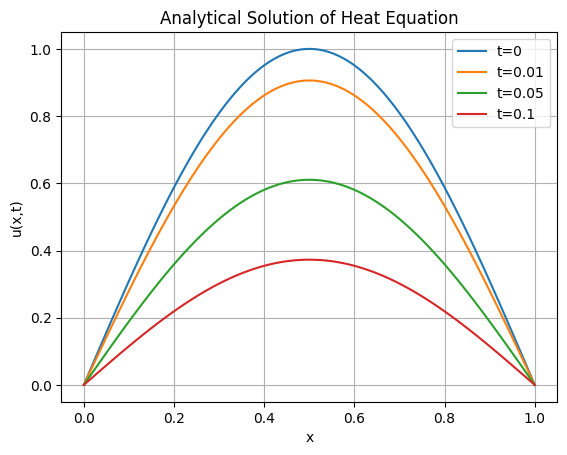

In [6]:
modes = get_modes()

plot_solution(
    x,
    times,
    analytical_solution,
    alpha=alpha,
    modes=modes
)